In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

transactions_clean = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])
customers_clean    = pd.read_csv("clean_data/customers_clean.csv")

print("Données chargées ✓")

Données chargées ✓


In [8]:
print("\n\n------------------------------------------------ ETAPE 1.a : Construction des features RFM ----------------------------------------------")
print("\n1) À partir de transactions.csv nettoyé, calculez pour chaque client Recence / fréquence / montant")

# La snapshot date = date max du dataset (pas la date du jour)
snapshot_date = transactions_clean["invoice_date"].max()
print(f"\nSnapshot date : {snapshot_date.date()}")

print("\n====== CALCUL RFM ======")
rfm = transactions_clean.groupby("customer_id").agg(
    recence   = ("invoice_date", lambda dates: (snapshot_date - dates.max()).days),
    frequence = ("invoice_id",   "nunique"),
    montant   = ("line_total",   "sum")
).reset_index()
print(f"\nNombre de clients dans la table RFM : {len(rfm)}")
print("\nAperçu :")
print(rfm.head(20).to_string(index=False))

print("\n====== TOP 15 PAR RÉCENCE (plus récent → moins récent) ======")
print(rfm.sort_values("recence",
ascending=True).head(15).to_string(index=False))

print("\n====== TOP 15 PAR FRÉQUENCE (plus fréquent → moins fréquent) ======")
print(rfm.sort_values("frequence",
ascending=False).head(15).to_string(index=False))

print("\n====== TOP 15 PAR MONTANT (plus gros → plus petit) ======")
print(rfm.sort_values("montant",
ascending=False).head(15).to_string(index=False))

print("\n====== FEATURES SUPPLEMENTAIRES ======")
print("--> Ajout du panier moyen et de l'ancienneté (tenure)")
rfm["panier_moyen"] = rfm["montant"] / rfm["frequence"]

customers_clean["first_purchase"] = pd.to_datetime(customers_clean["first_purchase"])
anciennete = customers_clean[["customer_id", "first_purchase"]].copy()
anciennete["anciennete_jours"] = (snapshot_date - anciennete["first_purchase"]).dt.days
rfm = rfm.merge(anciennete[["customer_id", "anciennete_jours"]], on="customer_id", how="left")

print("\nStatistiques :")
print(rfm[["recence", "frequence", "montant", "panier_moyen", "anciennete_jours"]].describe().round(1))



------------------------------------------------ ETAPE 1.a : Construction des features RFM ----------------------------------------------

1) À partir de transactions.csv nettoyé, calculez pour chaque client Recence / fréquence / montant

Snapshot date : 2026-06-30

====== CALCUL RFM ======

Nombre de clients dans la table RFM : 47662

Aperçu :
 customer_id  recence  frequence  montant
     12346.0      325          3   500.56
     12347.0        1          8  6472.20
     12348.0       74          5  1537.84
     12349.0       18          3  5085.38
     12350.0      309          1   459.45
     12351.0      374          1   632.28
     12352.0       35          9  3096.61
     12353.0      203          2   780.89
     12354.0      231          1  2083.84
     12355.0      213          2   900.58
     12356.0       22          6  3517.13
     12358.0        1          5  1741.74
     12360.0       51          6  6032.58
     12361.0      286          4  1179.56
     12362.0        2

In [9]:
print("\n\n------------------------------------------------ ETAPE 1.b : Scoring RFM par saison ----------------------------------------------")

# Définition des saisons
saisons = {
    "Q1_janv_mars" : [1, 2, 3],
    "Q2_avr_juin"  : [4, 5, 6],
    "Q3_juil_sept" : [7, 8, 9],
    "Q4_oct_dec"   : [10, 11, 12]
}

transactions_clean["mois"] = transactions_clean["invoice_date"].dt.month

rfm_saisons = {}

for nom_saison, mois in saisons.items():
    print(f"\n====== {nom_saison} ======")

    # Filtrer les transactions de la saison
    tx_saison = transactions_clean[transactions_clean["mois"].isin(mois)].copy()

    # Date de fin de saison = dernier jour du dernier mois de la saison
    snapshot_saison = tx_saison["invoice_date"].max()

    # Calcul RFM pour cette saison
    rfm_s = tx_saison.groupby("customer_id").agg(
        recence   = ("invoice_date", lambda dates: (snapshot_saison - dates.max()).days),
        frequence = ("invoice_id",   "nunique"),
        montant   = ("line_total",   "sum")
    ).reset_index()

    # Scoring par quintiles (rang)
    rfm_s["score_R"] = pd.qcut(rfm_s["recence"],   q=5, labels=[5, 4, 3, 2, 1])
    rfm_s["score_F"] = pd.qcut(rfm_s["frequence"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])
    rfm_s["score_M"] = pd.qcut(rfm_s["montant"].rank(method="first"),   q=5, labels=[1, 2, 3, 4, 5])

    rfm_s["score_RFM"] = rfm_s["score_R"].astype(str) + rfm_s["score_F"].astype(str) + rfm_s["score_M"].astype(str)
    rfm_s["saison"]    = nom_saison

    print(f"Clients actifs : {len(rfm_s)}")
    print(rfm_s[["customer_id", "recence", "frequence", "montant", "score_R", "score_F", "score_M", "score_RFM"]].head(50).to_string(index=False))

    rfm_saisons[nom_saison] = rfm_s

# Table complète toutes saisons
rfm_all_saisons = pd.concat(rfm_saisons.values(), ignore_index=True)
print(f"\nTable RFM toutes saisons : {len(rfm_all_saisons)} lignes")
print(rfm_all_saisons.groupby("saison")["customer_id"].count())



------------------------------------------------ ETAPE 1.b : Scoring RFM par saison ----------------------------------------------

====== Q1_janv_mars ======
Clients actifs : 26024
 customer_id  recence  frequence  montant score_R score_F score_M score_RFM
     12346.0      438          1   428.16       1       1       5       115
     12347.0       38          1   622.08       4       1       5       415
     12358.0       59          1   208.95       3       1       4       314
     12360.0       21          1   843.14       4       1       5       415
     12361.0      371          1   236.48       2       1       4       214
     12362.0       29          2  1043.06       4       3       5       435
     12363.0       18          1   194.38       5       1       4       514
     12364.0       21          1   807.78       4       1       5       415
     12375.0        7          1   358.44       5       1       5       515
     12379.0       78          2   803.17       3       

In [10]:
print("\n\n------------------------------------------------ ETAPE 2 : Labellisation des segments RFM ----------------------------------------------")

# Labels connus
labels_connus = {
    "555" : "Champions",
    "511" : "Nouveaux prometteurs",
    "155" : "À risque",
    "111" : "Perdus",
    "333" : "Clients moyens"
}

rfm_all_saisons["segment"] = rfm_all_saisons["score_RFM"].map(labels_connus).fillna("Non labellisé")

print("\n====== RÉPARTITION DES SEGMENTS CONNUS ======")
segments_connus = rfm_all_saisons[rfm_all_saisons["segment"] != "Non labellisé"]
print(segments_connus.groupby(["saison", "segment"])["customer_id"].count().to_string())

print("\n====== SCORES NON LABELLISÉS — répartition par proportion ======")
non_labelises = rfm_all_saisons[rfm_all_saisons["segment"] == "Non labellisé"]
distribution = (
    non_labelises.groupby("score_RFM")["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"customer_id": "nb_clients"})
    .sort_values("nb_clients", ascending=False)
)
distribution["pct"] = (distribution["nb_clients"] / len(rfm_all_saisons) * 100).round(2)
print(distribution.to_string(index=False))



------------------------------------------------ ETAPE 2 : Labellisation des segments RFM ----------------------------------------------

====== RÉPARTITION DES SEGMENTS CONNUS ======
saison        segment             
Q1_janv_mars  Champions               1257
              Clients moyens           236
              Nouveaux prometteurs     123
              Perdus                   613
              À risque                  62
Q2_avr_juin   Champions               1595
              Clients moyens           243
              Nouveaux prometteurs      61
              Perdus                   787
              À risque                  55
Q3_juil_sept  Champions                960
              Clients moyens           154
              Nouveaux prometteurs     157
              Perdus                   416
              À risque                  62
Q4_oct_dec    Champions               1134
              Clients moyens           213
              Nouveaux prometteurs     152
     

In [11]:
print("\n====== RÈGLE ±1 POINT : assignation des scores proches ======")
print("--> Si un score est à 1 point de distance d'un segment connu, on l'y rattache")

non_labelises_avant = (rfm_all_saisons["segment"] == "Non labellisé").sum()
print(f"\nNon labellisés AVANT règle ±1 : {non_labelises_avant} ({non_labelises_avant/len(rfm_all_saisons)*100:.1f}%)")

def distance_rfm(score_a, score_b):
    return sum(abs(int(a) - int(b)) for a, b in zip(score_a, score_b))

def assigner_segment(score_rfm):
    if score_rfm in labels_connus:
        return labels_connus[score_rfm]
    candidats = {label: distance_rfm(score_rfm, score)
                 for score, label in labels_connus.items()}
    min_distance = min(candidats.values())
    if min_distance == 1:
        return min(candidats, key=candidats.get)
    return "Non labellisé"

rfm_all_saisons["segment_v2"] = rfm_all_saisons["score_RFM"].apply(assigner_segment)

non_labelises_apres = (rfm_all_saisons["segment_v2"] == "Non labellisé").sum()
print(f"Non labellisés APRÈS règle ±1 : {non_labelises_apres} ({non_labelises_apres/len(rfm_all_saisons)*100:.1f}%)")
print(f"Récupérés par la règle        : {non_labelises_avant - non_labelises_apres} clients")

recap = (
    rfm_all_saisons.groupby("segment_v2")["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"customer_id": "nb_clients"})
    .sort_values("nb_clients", ascending=False)
)
recap["pct"] = (recap["nb_clients"] / len(rfm_all_saisons) * 100).round(1)
print(f"\n{recap.to_string(index=False)}")


====== RÈGLE ±1 POINT : assignation des scores proches ======
--> Si un score est à 1 point de distance d'un segment connu, on l'y rattache

Non labellisés AVANT règle ±1 : 92124 (91.3%)
Non labellisés APRÈS règle ±1 : 71998 (71.3%)
Récupérés par la règle        : 20126 clients

          segment_v2  nb_clients  pct
       Non labellisé       71998 71.3
           Champions       11147 11.0
              Perdus        7571  7.5
      Clients moyens        6271  6.2
Nouveaux prometteurs        2343  2.3
            À risque        1589  1.6


In [12]:
print("\n====== SCORES NON LABELLISÉS RESTANTS ======")

non_labelises_restants = rfm_all_saisons[rfm_all_saisons["segment_v2"] == "Non labellisé"]

distribution_restants = (
    non_labelises_restants.groupby("score_RFM")["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"customer_id": "nb_clients"})
    .sort_values("nb_clients", ascending=False)
)
distribution_restants["pct"] = (distribution_restants["nb_clients"] / len(rfm_all_saisons) * 100).round(2)

print(f"Scores distincts non labellisés : {distribution_restants['score_RFM'].nunique()}")
print(f"Clients non labellisés          : {distribution_restants['nb_clients'].sum()}")
print(f"\nDistribution des nb_clients par score :")
print(distribution_restants["nb_clients"].describe().round(0))
print(f"\nListe complète :")
print(distribution_restants.to_string(index=False))


====== SCORES NON LABELLISÉS RESTANTS ======
Scores distincts non labellisés : 102
Clients non labellisés          : 71998

Distribution des nb_clients par score :
count     102.0
mean      706.0
std       497.0
min         3.0
25%       308.0
50%       626.0
75%      1061.0
max      1851.0
Name: nb_clients, dtype: float64

Liste complète :
score_RFM  nb_clients  pct
      131        1851 1.83
      221        1850 1.83
      454        1832 1.82
      444        1710 1.69
      122        1699 1.68
      355        1682 1.67
      321        1599 1.58
      544        1526 1.51
      222        1482 1.47
      443        1469 1.46
      354        1404 1.39
      132        1404 1.39
      344        1395 1.38
      244        1314 1.30
      543        1292 1.28
      322        1264 1.25
      421        1262 1.25
      113        1255 1.24
      243        1224 1.21
      231        1204 1.19
      215        1170 1.16
      123        1160 1.15
      212        1116 1.11
      42

In [13]:
print("\n====== SCORES NON LABELLISÉS — du plus proche de Champion au plus proche de Perdu ======")

distribution_restants["dist_champion"] = distribution_restants["score_RFM"].apply(lambda score: distance_rfm(score, "555"))
distribution_restants["dist_perdu"]    = distribution_restants["score_RFM"].apply(lambda score: distance_rfm(score, "111"))

distribution_restants_trie = distribution_restants.sort_values(
    ["dist_champion", "dist_perdu"],
    ascending=[True, False]
)

print(distribution_restants_trie[["score_RFM", "nb_clients", "pct", "dist_champion", "dist_perdu"]].to_string(index=False))


====== SCORES NON LABELLISÉS — du plus proche de Champion au plus proche de Perdu ======
score_RFM  nb_clients  pct  dist_champion  dist_perdu
      454        1832 1.82              2          10
      355        1682 1.67              2          10
      544        1526 1.51              2          10
      445         752 0.75              2          10
      553         707 0.70              2          10
      535         676 0.67              2          10
      444        1710 1.69              3           9
      354        1404 1.39              3           9
      543        1292 1.28              3           9
      453         612 0.61              3           9
      435         610 0.60              3           9
      345         601 0.60              3           9
      534         560 0.55              3           9
      552         181 0.18              3           9
      525          19 0.02              3           9
      443        1469 1.46              4     

In [14]:
print("\n====== LABELLISATION FINALE DES NON LABELLISÉS ======")

def labelliser_restant(score_rfm):
    R, F, M = int(score_rfm[0]), int(score_rfm[1]), int(score_rfm[2])

    if distance_rfm(score_rfm, "555") <= 3:
        return "Potentiels Champions"
    if R <= 2 and F >= 3 and M >= 3:
        return "VIP endormis"
    if F >= 4 and M <= 2:
        return "Fréquents économes"
    return "Inclassable"

rfm_all_saisons["segment_v3"] = rfm_all_saisons.apply(
    lambda row: labelliser_restant(row["score_RFM"]) if row["segment_v2"] == "Non labellisé" else row["segment_v2"],
    axis=1
)

recap_v3 = (
    rfm_all_saisons.groupby("segment_v3")["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"customer_id": "nb_clients"})
    .sort_values("nb_clients", ascending=False)
)
recap_v3["pct"] = (recap_v3["nb_clients"] / len(rfm_all_saisons) * 100).round(1)

print(recap_v3.to_string(index=False))

inclassables = (rfm_all_saisons["segment_v3"] == "Inclassable").sum()
print(f"\nInclassables restants : {inclassables} ({inclassables / len(rfm_all_saisons) * 100:.1f}%)")


====== LABELLISATION FINALE DES NON LABELLISÉS ======
          segment_v3  nb_clients  pct
         Inclassable       44581 44.2
Potentiels Champions       14164 14.0
           Champions       11147 11.0
        VIP endormis        8317  8.2
              Perdus        7571  7.5
      Clients moyens        6271  6.2
  Fréquents économes        4936  4.9
Nouveaux prometteurs        2343  2.3
            À risque        1589  1.6

Inclassables restants : 44581 (44.2%)



====== CHIFFRE D'AFFAIRES PAR MOIS — toutes années confondues ======


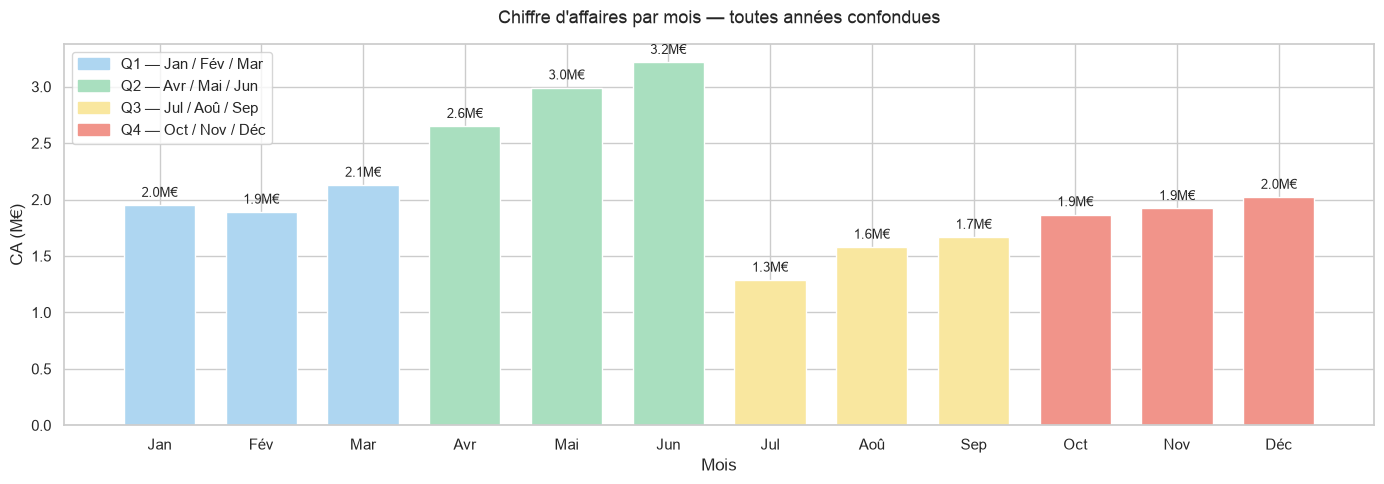

In [15]:
print("\n====== CHIFFRE D'AFFAIRES PAR MOIS — toutes années confondues ======")

from matplotlib.patches import Patch

ca_par_mois = (
    transactions_clean.groupby(transactions_clean["invoice_date"].dt.month)["line_total"]
    .sum()
    .reset_index()
    .rename(columns={"invoice_date": "mois", "line_total": "ca"})
)

noms_mois = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]
ca_par_mois["nom_mois"] = ca_par_mois["mois"].apply(lambda m: noms_mois[m - 1])

couleurs_saisons = {
    1: "#AED6F1", 2: "#AED6F1", 3: "#AED6F1",
    4: "#A9DFBF", 5: "#A9DFBF", 6: "#A9DFBF",
    7: "#F9E79F", 8: "#F9E79F", 9: "#F9E79F",
    10: "#F1948A", 11: "#F1948A", 12: "#F1948A"
}
couleurs = ca_par_mois["mois"].map(couleurs_saisons)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(ca_par_mois["nom_mois"], ca_par_mois["ca"] / 1e6, color=couleurs, edgecolor="white", width=0.7)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{bar.get_height():.1f}M€", ha="center", va="bottom", fontsize=9)

legende = [
    Patch(color="#AED6F1", label="Q1 — Jan / Fév / Mar"),
    Patch(color="#A9DFBF", label="Q2 — Avr / Mai / Jun"),
    Patch(color="#F9E79F", label="Q3 — Jul / Aoû / Sep"),
    Patch(color="#F1948A", label="Q4 — Oct / Nov / Déc"),
]
ax.legend(handles=legende, loc="upper left")
ax.set_title("Chiffre d'affaires par mois — toutes années confondues", fontsize=13, pad=15)
ax.set_xlabel("Mois")
ax.set_ylabel("CA (M€)")

plt.tight_layout()
plt.show()

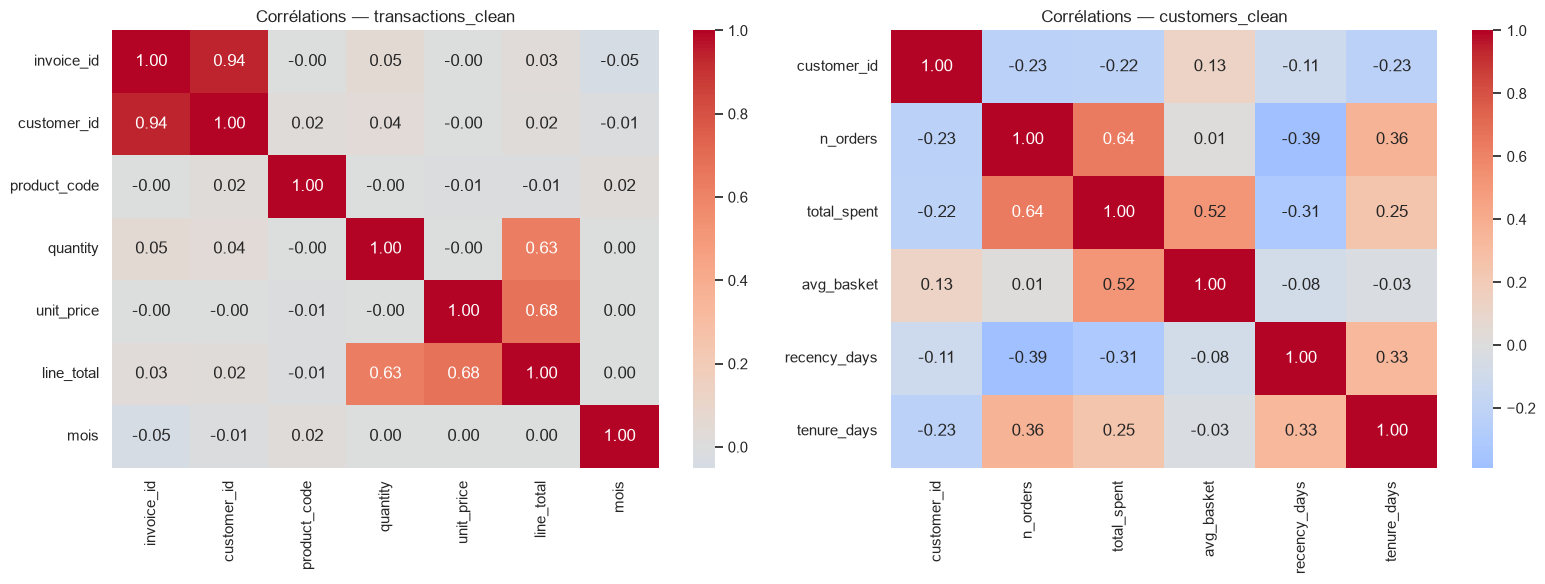

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap transactions_clean
corr_transactions = transactions_clean.select_dtypes(include="number").corr().round(2)
sns.heatmap(corr_transactions, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0])
axes[0].set_title("Corrélations — transactions_clean")

# Heatmap customers_clean
corr_customers = customers_clean.select_dtypes(include="number").corr().round(2)
sns.heatmap(corr_customers, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[1])
axes[1].set_title("Corrélations — customers_clean")

plt.tight_layout()
plt.show()